## Simple polynomial Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# random generator
rng = np.random.default_rng(seed=42)

#### Generating some polynomial dataset

In [3]:
X = 6 * rng.random((100,1)) - 3
y = 2 + (1.5*X) + (0.5 * (X**2)) + rng.random((100,1))

<Axes: >

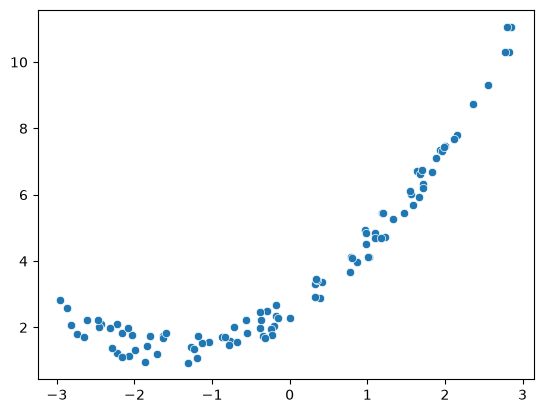

In [4]:
sns.scatterplot(x=X[:,0],y=y[:,0])

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.3)

### First let's test with SimpleLInear Regression

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lin_reg = LinearRegression()

In [9]:
reg_model = lin_reg.fit(X_train,y_train)

In [10]:
y_pred = reg_model.predict(X_test)

In [11]:
# R2 Score
reg_model.score(X_test,y_test)

0.8077288104367797

In [12]:
# MSE, MAE
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute error ", mae)
print("Mean Square error ", mse)

Mean Absolute error  0.9181806928720306
Mean Square error  1.460297306751668


### Visualizing the linear regression model plot on x data

<Axes: >

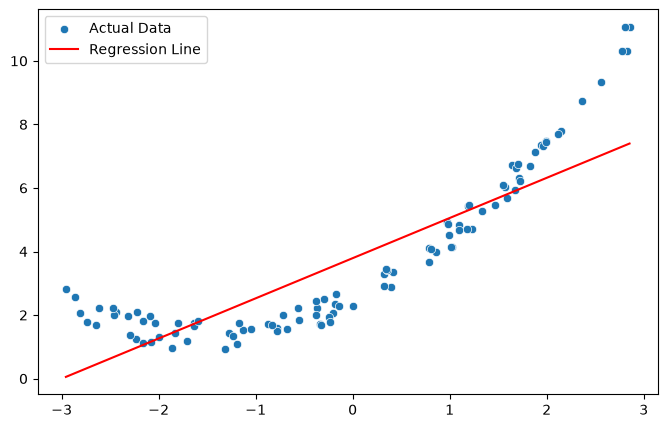

In [13]:

# Create evenly spaced x values
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

# Predict y values
y_vals = reg_model.intercept_[0] + reg_model.coef_[0][0] * x_vals

plt.figure(figsize=(8,5))

# Scatter plot
sns.scatterplot(x=X[:, 0], y=y[:, 0], label="Actual Data")

# Regression line
sns.lineplot(x=x_vals, y=y_vals, color="red", label="Regression Line")

## Solving the same dataset with Simple Polynomial Regression Model

#### Polynomial regression is nothing but Linear regression applies to polynomial features.
So here are just synthesizing new feature, and that feature is based on already feature with some polynomial degree

In [14]:
from sklearn.preprocessing import PolynomialFeatures

In [15]:
poly = PolynomialFeatures(degree=2)

In [16]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [17]:
X_train_poly[:5,:] # showing only 5 rows

array([[ 1.        ,  2.56058993,  6.55662081],
       [ 1.        , -1.27003138,  1.6129797 ],
       [ 1.        , -2.45971284,  6.05018723],
       [ 1.        , -2.07426305,  4.30256719],
       [ 1.        , -0.71387264,  0.50961415]])

In [18]:
## Now applying Linear Regression on this Polynomial features

In [19]:
lin_reg_poly = LinearRegression()

In [20]:
reg_poly = lin_reg_poly.fit(X_train_poly,y_train)

In [21]:
#R2 Score
reg_poly.score(X_test_poly,y_test)

0.9873846456583587

#### Here we can see that, after using polynomial regression the R2 Score increases

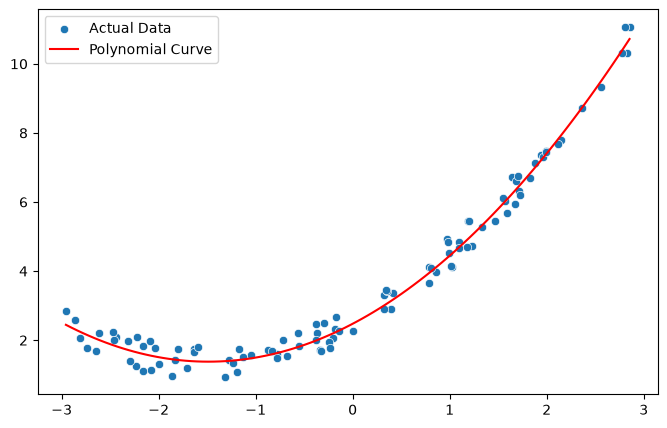

In [22]:
# Create evenly spaced x values
x_vals = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Convert to polynomial features
x_poly_vals = poly.transform(x_vals)

# Predict
y_vals = reg_poly.predict(x_poly_vals)

plt.figure(figsize=(8,5))

# Scatter plot
sns.scatterplot(x=X[:, 0], y=y[:, 0], label="Actual Data")

# Polynomial regression curve
sns.lineplot(x=x_vals[:, 0], y=y_vals[:, 0], color="red", label="Polynomial Curve")

plt.show()